# Carl von Ossietzky Universität Oldenburg - Mapping

In [8]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [10]:
client = bigquery.Client(project='subugoe-collaborative')

In [13]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        'Carl von Ossietzky Universität Oldenburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              99, -- 'Carl von Ossietzky Universität Oldenburg'
                              445, -- 'Evangelisches Krankenhaus Oldenburg'
                              6612, -- 'UMO - Universitätsmedizin Oldenburg'
                              316, -- 'Klinikum Oldenburg gGmbH'
                              315, -- 'Pius-Hospital Oldenburg'
                              5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                              4564 -- Institute for Science Networking Oldenburg GmbH
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [14]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Carl von Ossietzky Universität Oldenburg,University Hospital for Orthopaedics and Traum...,https://openalex.org/W4281920284
1,not assigned,Carl von Ossietzky Universität Oldenburg,"Institute of Physics, University of Oldenburg ...",https://openalex.org/W4295981023
2,not assigned,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky University of Oldenburg, Un...",https://openalex.org/W4313471873
3,not assigned,Carl von Ossietzky Universität Oldenburg,"Research Center Neurosensory Science, Carl von...",https://openalex.org/W4311180475
4,not assigned,Carl von Ossietzky Universität Oldenburg,"Department of Neurology, School of Medicine an...",https://openalex.org/W4311180475


In [15]:
#oal.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [62]:
MAPPING_DICT = {
    'Bibliotheks- und Informationssystem (BIS)': ['informationssystem'],
    'Center für lebenslanges Lernen (C3L)': ['lifelong learning', 'center für lebenslanges lernen'],
    #'CMC - Center for Migration, Education and Cultural Studies': [],
    'COAST - Zentrum für Umwelt- und Nachhaltigkeitsforschung': ['sustainability research', 'coast-zentrum'],
    #'ecco-ecology + communication Unternehmensberatung GmbH': [],
    'Fakultät I - Bildungs- und Sozialwissenschaften': ['(department|institute) (for|of) social science', '(school|institute|faculty|department) of education(al)?', 
                                                        'educational science', 'special (education|needs)', 'lernforschung',
                                                        'rehabilitation', 'research on learning', 'pedagogy', 'schooling', 
                                                        '(open|political|continuing) (education|theory)', 'department i educational',
                                                        'sozialwissenschaft(liche|en)', '(?<!religions)(?<!wirtschafts)päd(a)?gogik', 'social sciences institute'
                                                       ],
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': ['(business|energy) (informati(on|cs)|application|administration)', 
                                                                        'applied artific(i)?al intelligence', 'information technology',
                                                                        'digitalized', '(department|fachbereich|media)( of| für)? (economics|informati(k|cs)|business)', 
                                                                        'comput(er|ing) science', 'offis', 'sustainable information', 'economic(s and)? law', 
                                                                        'resilience learning', 'vwl', 'marketing', 'safety-security',
                                                                        'interconnected systems', '(public|ecological) economics', 'wirtschaftspädagogik', 'micro(-)?robotics',
                                                                        'rechtswissenschaften', 'finance and banking', 'medieninformatik', 
                                                                        'software engineering', 'accounting', 'innovation', 'formale sprachen', 
                                                                        'informatics (department|education)', 'embedded hardware', 'computational intelligence', 
                                                                        'safety and explainability', 'betriebswirtschaft', 'chair of management'
                                                                       ],
    'Fakultät III - Sprach- und Kulturwissenschaften': ['(institut(e)?|department) (of|für) musi(k|c)', 'kulturwissenschaften',
                                                        'department of (german|dutch)', 'visuelle kultur', '(german|american|slavic|dutch) studies',
                                                        'musicology', 'linguistics', '(niederland|sla(w|v)|german)istik', 'slavic department', 
                                                        'speech and music lab'
                                                       ],
    'Fakultät IV - Human- und Gesellschaftswissenschaften': ['philosoph(ie|y)', 'department of history', 'religionspädagogik', 'institut für geschichte',
                                                             'so(z|c)iolog(ie|y)', 'historisches institut', 'school iv', 'institute of history',
                                                             'theolog(ie|y)', 'sportwissenschaft', 'fak. iv', 'sport(s)? science'
                                                            ],
    'Fakultät V - Mathematik und Naturwissenschaften': ['(icbm)', 'chemi(e|stry) (und|and) biolog(ie|y)', 'industrial chemistry',
                                                        '(ins(t)?(i)?tut(e)?|department|school) (of|f(ü|u|ue)?r|at|for) (ch(e)?mi(e|stry)|physi(k|cs)|biolog(ie|y))', 
                                                        'animal navigation', 'biologie und umweltwissenschaften',
                                                        '(environmental|natural) science', 'nanoscale', 'mathemati(k|cs|sches)', 
                                                        'dida(k|c)ti(k|cs) (der|of) (chemi(e|stry)|physi(k|cs))', 'geodiversity',
                                                        '(physics|chemistry) department', 'sustainable energy', '(landscape|aquatic) ecology', 'geology', 
                                                        '(angewandte|technische|applied|physical|theoretical|organische|marine) chemi(e|stry)', 
                                                        'chemical engineering', 'ecology of plants', 'theoretical physic', 'gewässerökologie',
                                                        'evolutionsbiologie', 'marine sensor(ik|s)', 'genomics', 'evolutionary biology', '(plant|functional) ecology',
                                                        '(chemistry|physics) education', 'soil sci.', 'ag marine biodiversität'
                                                       ],
    'Fakultät VI - Medizin und Gesundheitswissenschaften': ['neuro(science|surgery|log(ie|y)|imaging)', 'anatom(ie|y)', 'health(\s)?(service|science|care)', 
                                                            'department of psychology', 'microbiology', 'laboratory medicine',
                                                            'geriatric', 'dermatology', 'allergologie', 'human medicine', 'gyn(a)?ecology', 'ophthalmology',
                                                            'acoust(.|ics)', 'surgery', 'fa(c|k)ult(ät|y) (6|vi)', 'pulmonology',  
                                                            'psychiatr(ie|y)', 'machine learning division', 'urology',
                                                            'hearing', 'versorgungsforschung', 'gesundheit', 'h(ä|e)matolog(ie|y)', 'oncology',
                                                            'psycholog(ie|y)', 'geneti(k|cs)', 'biometr(ie|y)', 'medizinische (physik|informatik)', 
                                                            'toxicology', 'clinical diagnostics', 'public health', 'medizintechnik',
                                                            'ernährung und funktionalität', 'medical device', 'big data in medicine',
                                                            'intensivmedizin', 'psychosomatik', 'pediatrics', 'klinische chemie',
                                                            'ohrenheilkunde', 'psychological methods', 'signal processing', 'space environment',
                                                            'immunol(.|ogy)', 'ethics in medicine', 
                                                            'medical (phys(.|ics)|informatics|technolog|radiation)', 
                                                            'ethik in der medizin', 'anesthesiology', 'pädiatrie', 'psychosomatic', 'allgemeinmedizin',
                                                            'otorhinolaryngology', 'emergency', 'ambulante', 'pathologie',
                                                            'ai4health', 
                                                          ],
    'Forschungszentrum Neurosensorik': ['cent(re|er)( for| of)? neurosensory', 'forschungszentrum( für)? neurosensorik', 'ag ("|‘)(neuro)?sens'],
    'ForWind - Zentrum für Windenergieforschung': ['wind energy', 'forwind'],
    'Hochschulsport': ['sport(s)? cent(re|er)'],
    #'Institute for Science Networking Oldenburg GmbH': [],
    #'Oldenburger Fortbildungszentrum (OFZ)': [],
    #'Zentrum für interdisziplinäre Frauen- und Geschlechterforschung (ZFG)': [],
    #'Zentrum für Lehrkräftebildung - Didaktisches Zentrum (DIZ)': [],
    'Helmholtz-Institut für Funktionelle Marine Biodiversität': ['(hifmb)', 'helm(h)?oltz(-|‐|\s)?institute'], # selbst ergänzt
    'Universitätsmedizin Oldenburg': ['universitätsmedizin', 'klinik', 'hospital', 'krankenhaus', 'gastroenterolog(ie|y)', 'oldenburg clinic',
                                      'universit(y|äts)(\s)?(klinik|medi(c|z)in(e)?)', 'pius', 'klinikum oldenburg', 'department of cardiology',
                                      'cardiology research group',
                                      'radiolog(ie|y)', '(medical|medizinischer) (k|c)ampus', 'university medicine', 'general practice', ] # selbst ergänzt
}

In [63]:
with open('./mapping_tables_fak/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [64]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [65]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [66]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,University Hospital for Orthopaedics and Traum...,https://openalex.org/W4281920284
1,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,"Institute of Physics, University of Oldenburg ...",https://openalex.org/W4295981023
2,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky University of Oldenburg, Un...",https://openalex.org/W4313471873
3,Forschungszentrum Neurosensorik,Carl von Ossietzky Universität Oldenburg,"Research Center Neurosensory Science, Carl von...",https://openalex.org/W4311180475
4,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Neurology, School of Medicine an...",https://openalex.org/W4311180475
...,...,...,...,...
14037,None,Carl von Ossietzky Universität Oldenburg,Institut für Technische Informatik (4480),https://openalex.org/W3009612243
14038,None,Carl von Ossietzky Universität Oldenburg,Institut für Technische Informatik (4480),https://openalex.org/W3093913884
14039,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,"Industrial Chemistry II, Carl von Ossietzky Un...",https://openalex.org/W3011199974
14040,"Fakultät II - Informatik, Wirtschafts- und Rec...",Carl von Ossietzky Universität Oldenburg,Department of Ecological Economics Carl von Os...,https://openalex.org/W3012349403


In [67]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Oldenburg',
       'Carl von Ossietzky Universität Oldenburg',
       'University of Oldenburg, Germany',
       'Carl von Ossietzky University Oldenburg, Oldenburg,  Germany',
       'Univ. Oldenburg (Germany)',
       'Carl von Ossietzky University of Oldenburg',
       'Carl von Ossietzky University of Oldenburg, Carl von Ossietzky-Str. 9-11, Oldenburg, 26111, Germany',
       'Carl von Ossietzky Universität Oldenburg, Germany',
       'Carl von Ossietzky University, European Medical School Oldenburg-Groningen, Oldenburg, Germany',
       'University of Oldenburg,Germany',
       'Carl von Ossietzky Universität Oldenburg Oldenburg, Niemcy',
       'Carl von Ossietzky University, Ammerländer Heerstraße 114-118, 26129, Oldenburg, Germany',
       'Institut für Technische Informatik (4480)',
       'Carl von Ossietzky University of Oldenburg , Oldenburg, Germany',
       'Carl von Ossietzky University Oldenburg, Germany, --- Select a Country ---',
       'Carl von

In [68]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Bibliotheks- und Informationssystem (BIS),6
1,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,13
2,Center für lebenslanges Lernen (C3L),4
3,Fakultät I - Bildungs- und Sozialwissenschaften,389
4,"Fakultät II - Informatik, Wirtschafts- und Rec...",650
5,Fakultät III - Sprach- und Kulturwissenschaften,129
6,Fakultät IV - Human- und Gesellschaftswissensc...,187
7,Fakultät V - Mathematik und Naturwissenschaften,3729
8,Fakultät VI - Medizin und Gesundheitswissensch...,3833
9,ForWind - Zentrum für Windenergieforschung,46


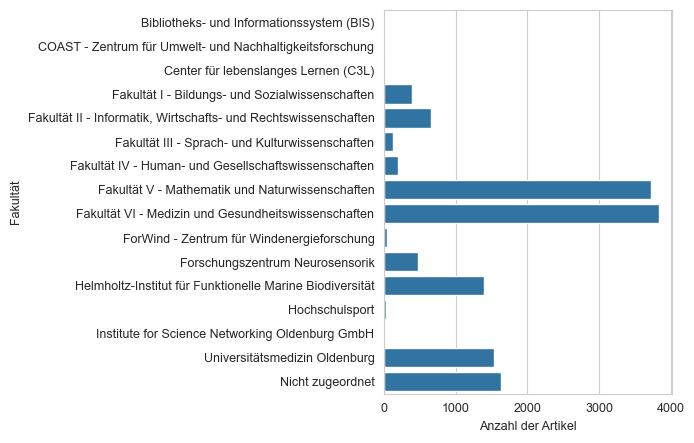

In [69]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [70]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8833499501495513

In [71]:
MAPPING_DICT_DEPT = {
    'Fakultät I - Bildungs- und Sozialwissenschaften': {
        'Institut für Pädagogik': ['institut für päd(a)?gogik', '(department|institute) (of|for) (pedagogy|educational science)', 'educational psychology',
                                   'empirical research on learning', 'center for open education', 'lehr-lernforschung', 'institute of education'
                                  ],
        'Institut für Sonder- und Rehabilitatiospädagogik': ['special (educational )?(needs|education)', 'rehabilitation'],
        'Institut für Sozialwissenschaften': ['(institute|department) (for|of) social science', 'institut (für|fÃ¼r) sozialwissenschaften', 
                                              'political (theory|education)', 'social sciences institute', 'sozialwissenschaftliche theorie'
                                             ],
    },
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': {
        'Department für Informatik': ['informatics education', 'institute (for|of) information technology', '(media|business|energy) informatics', 
                                      'dep(t.|ar(t)?(e)?ment) (of( of)?|for|für) (comput(er|ing) science|informati(k|cs))', 'digitalized energy', 
                                      'medieninformatik', 'sustainable information',
                                      'distributed control', '(artific(i)?al|computational) intelligence', 'fachbereich informatik', 'formale sprachen',
                                      'offis', 'explainability', 'comput(er|ing) science department', 'business application', 'micro(-)?roboti(k|cs)',
                                      'resilience learning', 'software engineering', 'embedded'
                                     ],
        'Department für Wirtschafts- und Rechtswissenschaften': ['institute of economics', 'department of (business administration|economics)', 
                                                                 '(economic|environmental) law', 'wirtschaftspädagogik', 'rechtswissenschaften',
                                                                 'innovation', 'ecological economic', 'vwl', 'finance and banking', 'accounting',
                                                                 'marketing', 'betriebswirtschaft'
                                                                ],
    },
    'Fakultät III - Sprach- und Kulturwissenschaften': {
        'Institut für Anglistik und Amerikanistik': ['amerikanistik', 'anglistik', 'american studies'],
        'Institut für Germanistik': ['germanistik', 'german (studies|language)', 'department of german'],
        'Institut für Kunst und visuelle Kultur': ['visuelle kultur'],
        'Institut für Materielle Kultur': ['materielle kultur'],
        'Institut für Musik': ['musi(k|c)'],
        'Institut für Niederlandistik': ['niederlandistik', 'dutch studies', 'department of dutch'],
        'Institut für Slavistik': ['sla(w|v)istik', 'slavic (studies|department)'],
    },
    'Fakultät IV - Human- und Gesellschaftswissenschaften': {
        'Institut für Evangelische Theologie und Religionspädagogik': ['theolog(ie|y)'],
        'Institut für Geschichte': ['geschichte', 'history'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Sportwissenschaft': ['sport(s)? science', 'sportwissenschaft', 'so(z|c)iolog(ie|y)'],
    },
    'Fakultät V - Mathematik und Naturwissenschaften': {
        'Institut für Biologie und Umweltwissenschaften (IBU)': ['environmental (science|planning)', 'umweltwissenschaften', 'hydrolog(ie|y)', 'soil sci',
                                                                 '(landscape|plant|functional|aquatic) ecology', 'biodiversity', 
                                                                 'institut(e)? (für|for) biolog(ie|y)', 'neurosensor(ik|y)',
                                                                 'ecological genomics', 'evolutionsbiologie', 'gewässerökologie'
                                                                ],
        'Institut für Chemie (IfC)': ['(department|institut(e)?) (of|for|für) chemi(e|stry)(?!\sand)(?!\sund)', 'chemistry education', 
                                      '(organische|technische|angewandte) chemie',
                                      'didaktik der chemie', '(industrial|applied|physical|theoretical) chemistry', 'chemistry department',
                                      'chemical engineering'
                                     ],
        'Institut für Chemie und Biologie des Meeres (ICBM)': ['marine', 'meeres', 'icbm', 'institut(e)? (for|für) chemi(e|stry)'],
        'Institut für Mathematik (IFM)': ['(department|institut(e)?|school|inst.) (of|for|für|fÃ¼r|f(u)?r) mathemati(k|c)', 'mathematisches institut'],
        'Institut für Physik (IFP)': ['physi(k|cs)', 'nanoscale'],
    },
    'Fakultät VI - Medizin und Gesundheitswissenschaften': {
        'Department für Humanmedizin': ['human(\s)?medi(z|c)in', 'toxi(k|c)olog(ie|y)', 'mi(k|c)robiolog(ie|y)', 'neurosurgery', 'immunol(.|og(ie|y))',
                                        'ophthalmology', 'klinische chemie', 'dermatolog(ie|y)', 'pediatric', 'anatom(ie|y)', 'human genetics',
                                        'clinical chemistry', 'perinatal neurobiology', 'oncology', 'otorhinolaryngology', 'ohrenheilkunde',
                                        'intensivmedizin', 'urolog(ie|y)', 'gyn(a)?ecology', 'emergency', 'otolaryngology', 'genetics of childhood',
                                        '(cardiac|visceral|orthopaedic) surgery', 'anesthesiology', 'haematology', 'inflammation', 'internal medicine', 
                                        'humangenetik', 'medical education'
                                       ],
        'Department für Neurowissenschaften': ['neurolog(ie|y)', 'neuroscience', 'neurogenetics', 'neurosensory'],
        'Department für Psychologie': ['psycholog(ie|y)', 'psychotherap(ie|y)', 'psychiatry', 'psychological'],
        'Department für Versorgungsforschung': ['versorgungsforschung', 'health services research', 'ethi(k|cs)', 'epidemiolog(ie|y)',
                                                'assistance systems', 'assistenzsysteme', 'geriatri(e|c)', 'informatics', 'device technology',
                                                'allgemeinmedizin', 'ai4health', 'big data', 'assistive', 'medizinische informatik',
                                                'ernährung und funktionalität'
                                               ],
        'Department Medizinische Physik und Akustik': ['a(k|c)(o)?usti(k|c)', 'medizinische physik', 'hearing', 'radiation', 'signal processing',
                                                       'acoust.', 'machine learning', 'medical phys.'
                                                      ],
        'European Medical School Oldenburg-Groningen': ['european medical'],
        'Universitätsinstitut für Medizinische Genetik': ['medizinische genetik', 'medical genetics'],
        'Neuroimaging Unit': ['neuroimaging unit'] # selbst ergänzt
    }
}

In [72]:
with open('./mapping_tables_dept/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [73]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [74]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät VI - Medizin und Gesundheitswissenschaften')

In [75]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['University Hospital for Orthopaedics and Trauma Surgery Pius-Hospital, Medical Campus University of Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg',
       'University Hospital for Orthopaedics and Trauma Surgery Pius-Hospital Oldenburg, Medical Campus University of Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences Carl von Ossietzky University Oldenburg Oldenburg Germany',
       'School of Medicine and Health Sciences Carl von Ossietzky University Oldenburg  Oldenburg Germany',
       'Klinik für Hämatologie und Onkologie, Innere Medizin-Onkologie, Koordinator Cancer Center Oldenburg, Pius-Hospital, Medizinischer Campus Universität Oldenburg, Oldenburg, Deutschland',
       'Klinik für Hämatologie und Onkologie, Innere Medizin-Onkologie, Koordinator Cancer Center Oldenburg, Pius-Hospital, Medizinischer Campus Universität Oldenburg, Georgstr.\xa012, 26121 Oldenburg, Deutschland',
       'Univ

In [76]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Department Medizinische Physik und Akustik,817
1,Department für Humanmedizin,1148
2,Department für Neurowissenschaften,241
3,Department für Psychologie,599
4,Department für Versorgungsforschung,752
5,European Medical School Oldenburg-Groningen,22
6,Neuroimaging Unit,6
7,Universitätsinstitut für Medizinische Genetik,25
8,NaN,223


In [77]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
0,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,University Hospital for Orthopaedics and Traum...,https://openalex.org/W4281920284,None
2,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky University of Oldenburg, Un...",https://openalex.org/W4313471873,Department für Humanmedizin
4,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Neurology, School of Medicine an...",https://openalex.org/W4311180475,Department für Humanmedizin
5,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Division of Ethics in Medicine, Carl von Ossie...",https://openalex.org/W4291020057,Department für Versorgungsforschung
6,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Division of Ethics in Medicine, Carl von Ossie...",https://openalex.org/W4291020057,Department für Versorgungsforschung
...,...,...,...,...,...
14027,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Health Services Research, Divisi...",https://openalex.org/W3023509907,Department für Versorgungsforschung
14030,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Oldenburger Forschungsnetzwerk Notfall- und In...,https://openalex.org/W3031363062,Department für Humanmedizin
14032,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Medizinische Informatik, Department für Versor...",https://openalex.org/W3031363062,Department für Versorgungsforschung
14033,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Department of Medical Education and Educationa...,https://openalex.org/W3037739690,Department für Humanmedizin
